# CISC7204 Assignment 01 — Preliminary Project Proposal
## Phase-1 data analysis: *Is Macau's Transport Keeping Up With Its Visitors?*

**Course:** CISC7204 *Data Science and Data Visualization* (2026-1, class 001-E)
**Coursework item:** Assignment 01 — Preliminary Project Proposal (Individual/Pair)
**Student:** Fong Chin Wai, Vivi — mc653748
**Region:** Macao SAR, China · **Domain categories:** tourism / visitor economy and urban public transport

### Research question
> How does visitor demand (visitors by statistical district and by hour of day) align with Macao's
> public bus supply (routes, stops, scheduled departures) — and which districts are under- or
> over-served relative to the visitor load they carry?

### What this notebook does
1. Inventories the real datasets stored under `data/` and states which are usable for the demand × supply match.
2. Builds the **demand side**: DSEC monthly visitor arrivals (2008-01 → 2026-08) and the MGTO / data.gov.mo
   24-district × 24-hour visitor headcount panel (2023-01 → 2026-07), plus Golden-Week daily arrivals.
3. Builds the **supply side**: bus stop geography, route geography, stop-level scheduled bus departures
   (91 routes, 920 service windows), official fleet / stop-count / annual-ridership series and the
   hotel-casino shuttle quarterly ridership series.
4. **Matches supply against demand** at zone level, hour-of-day level, gateway level and event level.
5. Exports the merged analysis dataset (CSV) and a SQLite database, and renders the proposal figures.

### Honest caveat (kept from the project brief)
This analysis measures **alignment / accessibility gaps between transport supply and visitor demand**.
It does **not** claim that bus frequency *causes* visitation: every relationship reported below is
associational (correlation, share comparison, gap index) and is labelled as such.


In [1]:
import os, io, json, glob, math, re, sqlite3, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT   = r'C:\Users\07viv\Desktop\cisc7204-Assgn01-2026-mc653748'
DATA   = os.path.join(ROOT, 'data')
GOV    = os.path.join(DATA, 'gov_mo_datasets')
MGTO   = os.path.join(DATA, 'mgtodataplus')
DSEC   = os.path.join(DATA, 'dsec')
TS     = os.path.join(DATA, 'dsec_timeseries')
GH     = os.path.join(DATA, 'github_macau-bus-data', 'macau-bus-data-master')
SHP    = os.path.join(DATA, 'data.gov.mo_bus_route_shp', 'ExportShapeFile20260919')
MPB    = os.path.join(DATA, 'mopubbus')
PROC   = os.path.join(ROOT, 'data_processed')
FIGD   = os.path.join(ROOT, 'figures')
for d in (PROC, FIGD):
    os.makedirs(d, exist_ok=True)

def read_gov_xlsx(name, **kw):
    """data.gov.mo exports each table as a zip that also holds readme.json."""
    z = zipfile.ZipFile(os.path.join(GOV, name))
    inner = [n for n in z.namelist() if n.lower().endswith('.xlsx')][0]
    return pd.read_excel(io.BytesIO(z.read(inner)), **kw)

# Macro-zones used throughout: the 24 MGTO statistical districts collapse into 3 service zones.
ZONE_OF_CN = {
    # Macau Peninsula (17 districts)
    '下環區': 'Macau Peninsula', '中區': 'Macau Peninsula', '南西灣及主教山區': 'Macau Peninsula',
    '台山區': 'Macau Peninsula', '外港及南灣湖新填海區': 'Macau Peninsula', '新口岸區': 'Macau Peninsula',
    '新橋區': 'Macau Peninsula', '望廈及水塘區': 'Macau Peninsula', '東望洋區(松山區)': 'Macau Peninsula',
    '林茂塘區': 'Macau Peninsula', '沙梨頭及大三巴區': 'Macau Peninsula', '筷子基區': 'Macau Peninsula',
    '荷蘭園區': 'Macau Peninsula', '青洲區': 'Macau Peninsula', '高士德及雅廉訪區': 'Macau Peninsula',
    '黑沙環及祐漢區': 'Macau Peninsula', '黑沙環新填海區': 'Macau Peninsula',
    # Taipa & Cotai (6 districts)
    '北安及大潭山區': 'Taipa & Cotai', '大學及北安灣區': 'Taipa & Cotai', '氹仔中心區': 'Taipa & Cotai',
    '氹仔舊城及馬場區': 'Taipa & Cotai', '海洋及小潭山區': 'Taipa & Cotai', '路氹填海區': 'Taipa & Cotai',
    # Coloane (1 district)
    '路環區': 'Coloane',
}
ZONE_ORDER = ['Macau Peninsula', 'Taipa & Cotai', 'Coloane']
def esc(s):
    return str(s).encode('unicode_escape').decode()
print('workspace ready:', os.path.isdir(DATA), '| outputs ->', PROC, '|', FIGD)


workspace ready: True | outputs -> C:\Users\07viv\Desktop\cisc7204-Assgn01-2026-mc653748\data_processed | C:\Users\07viv\Desktop\cisc7204-Assgn01-2026-mc653748\figures


---
## 1. Dataset inventory and usability screen

Every dataset listed below is a real file already stored in the project folder; nothing is simulated.

In [2]:
inv = []
def add(group, name, path, note):
    p = os.path.join(ROOT, path)
    inv.append({'group': group, 'dataset': name, 'rel_path': path.replace('/', '\\'),
                'size_kb': round(os.path.getsize(p) / 1024, 1) if os.path.exists(p) else None,
                'role_in_analysis': note})
    return inv[-1]

add('Demand', 'DSEC Key Indicator 27 - monthly visitor arrivals', r'data\dsec_timeseries\DSEC_KeyIndicator_27.json',
    'Total visitor arrivals per month, 2008-01..2026-08 (224 months) - macro demand trend')
add('Demand', 'DSEC Key Indicator 127 - same-day visitor arrivals', r'data\dsec_timeseries\DSEC_KeyIndicator_127.json',
    'Same-day (non-overnight) arrivals per month - tourist type mix')
add('Demand', 'DSEC Key Indicator 28 - arrivals year-on-year change', r'data\dsec_timeseries\DSEC_KeyIndicator_28.json',
    'Year-on-year % change - growth context for 2025/2026')
add('Demand', 'MGTO Data+ district x hour visitor headcount (41 monthly files)', r'data\mgtodataplus\MacaoDistrictTourismData_YYYYMM_en.xlsx',
    '24 statistical districts x 24 hour slots visitor headcount, 2023-01..2026-07 - SPATIAL+TEMPORAL demand core')
add('Demand', 'data.gov.mo tidy district x hour headcount', r'data\gov_mo_datasets\dst_visitor_01_stats.xlsx',
    'Same indicator in tidy long form (2026 months 1-7) - independent copy / cross-check')
add('Demand', 'data.gov.mo district visits by origin', r'data\gov_mo_datasets\dst_visitor_02_stats.xlsx',
    'Person-time per district by origin - demand intensity by market')
add('Demand', 'Golden-week daily arrivals', r'data\gov_mo_datasets\dst_goldenweekvisitor.xlsx',
    'Daily total + mainland arrivals during Spring Festival / 1 October Golden Weeks (2017-2026) - event demand')
add('Supply', 'Bus stop master (routes/stops JSON)', r'data\github_macau-bus-data\macau-bus-data-master\stops.json',
    '586 bus stops with lat/lng - supply geography')
add('Supply', 'Bus route master (routes JSON)', r'data\github_macau-bus-data\macau-bus-data-master\routes.json',
    '91 routes with ordered stop lists - route geography and service intensity')
add('Supply', 'Route timetable / headway windows', r'data\github_macau-bus-data\macau-bus-data-master\route-schedule',
    '920 route-direction-time windows with headway (e.g. 4-8 min), weekday vs weekend - SUPPLY CAPACITY core')
add('Supply', 'DSAT bus network shapefiles + route sequence', r'data\data.gov.mo_bus_route_shp\ExportShapeFile20260919',
    'BUS_POLE/ROUTE_NETWORK shapes and BUS_ROUTE_SEQ.xls (23,535 stop-sequence rows) - official cross-check')
add('Supply', 'Official monthly public bus fleet', r'data\gov_mo_datasets\Number_of_buses.xlsx',
    'Buses in service by month, 2019-01.. - capacity stock')
add('Supply', 'Official monthly public bus stop count', r'data\gov_mo_datasets\Total_number_of public_bus_stops.xlsx',
    'Registered bus stops by month, 2019-01.. - network stock')
add('Supply', 'Official annual public bus ridership', r'data\gov_mo_datasets\Number_of_public_bus_rides.xlsx',
    'Annual passenger trips 2018..2025 (2025: 231,497,093) - realised load')
add('Supply', 'Hotel / casino shuttle ridership and departures', r'data\gov_mo_datasets\Hotel_casino_shuttle_bus_ridership_and_departure_frequency.xlsx',
    'Quarterly shuttle passenger trips + departures 2020Q1..2026Q1 - parallel tourist transport channel')
add('Supply', 'Land-port cross-border vehicle flow', r'data\gov_mo_datasets\陸路口岸跨境汽車流量(架次).xlsx',
    'Vehicles per land checkpoint per year - gateway pressure proxy')
add('Supply', 'Checkpoint arrivals/departures by residency', r'data\gov_mo_datasets\各入境事務站出入境人數.xlsx',
    'Annual in/out flows per checkpoint and residency group')
add('Event', 'MOPubBus smart-card/AVL trip records (figshare mirror)', r'data\mopubbus',
    'Trip-level passenger-flow level (0-5) and traffic condition (1-3) for routes 3 and AP1, normal vs Grand Prix weeks')

inv_df = pd.DataFrame(inv)
display(inv_df[['group', 'dataset', 'size_kb', 'role_in_analysis']])
inv_df.to_csv(os.path.join(PROC, 'dataset_inventory.csv'), index=False, encoding='utf-8-sig')

mg_files = sorted(glob.glob(os.path.join(MGTO, 'MacaoDistrictTourismData_*_en.xlsx')))
print('MGTO monthly district-hour files on disk:', len(mg_files))
print('coverage (file tags):', ' '.join(os.path.basename(f)[26:32] for f in mg_files))
print('total data folder size (MB):', round(sum(os.path.getsize(os.path.join(dp, f))
      for dp, _, fs in os.walk(DATA) for f in fs) / 1048576, 1))


,group,dataset,size_kb,role_in_analysis
0,Demand,DSEC Key Indicator 27 - monthly visitor arrivals,77.7,"Total visitor arrivals per month, 2008-01..202..."
1,Demand,DSEC Key Indicator 127 - same-day visitor arri...,77.7,Same-day (non-overnight) arrivals per month - ...
2,Demand,DSEC Key Indicator 28 - arrivals year-on-year ...,79.7,Year-on-year % change - growth context for 202...
3,Demand,MGTO Data+ district x hour visitor headcount (...,NaN,24 statistical districts x 24 hour slots visit...
4,Demand,data.gov.mo tidy district x hour headcount,142.0,Same indicator in tidy long form (2026 months ...
5,Demand,data.gov.mo district visits by origin,40.9,Person-time per district by origin - demand in...
6,Demand,Golden-week daily arrivals,21.7,Daily total + mainland arrivals during Spring ...
7,Supply,Bus stop master (routes/stops JSON),104.3,586 bus stops with lat/lng - supply geography
8,Supply,Bus route master (routes JSON),798.9,91 routes with ordered stop lists - route geog...
9,Supply,Route timetable / headway windows,12.0,920 route-direction-time windows with headway ...


MGTO monthly district-hour files on disk: 41
coverage (file tags): 02303_ 02304_ 02305_ 02306_ 02307_ 02308_ 02309_ 02310_ 02311_ 02312_ 02401_ 02402_ 02403_ 02404_ 02405_ 02406_ 02407_ 02408_ 02409_ 02410_ 02411_ 02412_ 025011 02501_ 02502_ 02503_ 02504_ 02505_ 02506_ 02507_ 02508_ 02509_ 02510_ 02512_ 02601_ 02602_ 02603_ 02604_ 02605_ 02606_ 02607_
total data folder size (MB): 46.5


---
## 2. Demand side — how many visitors, where, and at what hours

### 2.1 DSEC official monthly visitor arrivals (2008-01 → 2026-08)

In [3]:
MONTHS = {'Jan.': 1, 'Feb.': 2, 'Mar.': 3, 'Apr.': 4, 'May': 5, 'Jun.': 6,
          'Jul.': 7, 'Aug.': 8, 'Sep.': 9, 'Oct.': 10, 'Nov.': 11, 'Dec.': 12}

def ki_series(fname):
    raw = json.load(io.open(os.path.join(TS, fname), encoding='utf-8'))
    recs = []
    def walk(o):
        if isinstance(o, dict):
            if 'ReferencePeriod' in o and 'IndicatorValue' in o:
                recs.append(o)
            for v in o.values():
                walk(v)
        elif isinstance(o, list):
            for v in o:
                walk(v)
    walk(raw)
    df = pd.DataFrame([{'period': r['ReferencePeriod'], 'value': r['IndicatorValue']} for r in recs])
    df['value'] = pd.to_numeric(df['value'].astype(str).str.replace(',', ''), errors='coerce')
    df['year'] = df['period'].str.extract(r'(\d{4})').astype(int)
    df['month'] = df['period'].str.split('/').str[0].map(MONTHS)
    df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
    return df[['date', 'year', 'month', 'value']].dropna().sort_values('date').reset_index(drop=True)

arr = ki_series('DSEC_KeyIndicator_27.json').rename(columns={'value': 'arrivals'})
sameday = ki_series('DSEC_KeyIndicator_127.json').rename(columns={'value': 'same_day_arrivals'})
yoy = ki_series('DSEC_KeyIndicator_28.json').rename(columns={'value': 'arrivals_yoy_pct'})
dem = arr.merge(sameday[['date', 'same_day_arrivals']], on='date', how='left') \
         .merge(yoy[['date', 'arrivals_yoy_pct']], on='date', how='left')
dem['same_day_share_pct'] = 100 * dem['same_day_arrivals'] / dem['arrivals']
dem.to_csv(os.path.join(PROC, 'demand_monthly_arrivals.csv'), index=False, encoding='utf-8-sig')

print('monthly arrival series:', dem['date'].min().date(), '->', dem['date'].max().date(), '| n =', len(dem))
print('2025 total arrivals      :', f"{int(dem[dem.year == 2025].arrivals.sum()):,}")
print('2026 Jan-Aug arrivals    :', f"{int(dem[(dem.year == 2026) & (dem.month <= 8)].arrivals.sum()):,}",
      '| YoY first 8 months:',
      round(100 * (dem[dem.year == 2026].head(8).arrivals.sum() / dem[dem.year == 2025].head(8).arrivals.sum() - 1), 1), '%')
print('latest month             :', dem.iloc[-1]['date'].date(), f"{int(dem.iloc[-1]['arrivals']):,}",
      '| YoY', dem.iloc[-1]['arrivals_yoy_pct'], '%')
print('avg same-day share 2026  :', round(dem[dem.year == 2026]['same_day_share_pct'].mean(), 1), '%')
season = dem[dem.year.between(2015, 2019)].groupby('month')['arrivals'].mean()
season = 100 * season / season.mean()
print('seasonality index (2015-2019 mean = 100):')
print(season.round(1).to_string())


monthly arrival series: 2008-01-01 -> 2026-08-01 | n = 224
2025 total arrivals      : 40,069,360
2026 Jan-Aug arrivals    : 28,964,737 | YoY first 8 months: 7.7 %
latest month             : 2026-08-01 4,478,073 | YoY 6.14 %
avg same-day share 2026  : 61.4 %
seasonality index (2015-2019 mean = 100):
month
1      98.8
2     102.2
3      93.9
4     100.2
5      97.0
6      89.8
7     105.7
8     111.9
9      89.6
10    103.1
11    100.5
12    107.3


### 2.2 District × hour visitor headcount panel (MGTO Data+ / data.gov.mo, 2023-01 → 2026-07)

Each monthly file is year-to-date, so four files (`…202312`, `…202412`, `…202512`, `…202607`) reconstruct the
full 43-month panel of *24 districts × 24 hour slots*.

In [4]:
PANEL_FILES = ['MacaoDistrictTourismData_202312_en.xlsx', 'MacaoDistrictTourismData_202412_en.xlsx',
               'MacaoDistrictTourismData_202512_en.xlsx', 'MacaoDistrictTourismData_202607_en.xlsx']
frames = []
for f in PANEL_FILES:
    raw = pd.read_excel(os.path.join(MGTO, f), sheet_name='1', header=None)
    raw = raw[pd.to_numeric(raw[0], errors='coerce').notna()].copy()
    part = pd.DataFrame({
        'year': pd.to_numeric(raw[0]).astype(int),
        'month': pd.to_numeric(raw[1]).astype(int),
        'period': raw[2].astype(str).str.strip(),
        'district_cn': raw[3].astype(str).str.strip(),
        'district_en': raw[5].astype(str).str.strip(),
        'headcount': pd.to_numeric(raw[6], errors='coerce')})
    frames.append(part)
    print(f, '->', len(part), 'rows | months', sorted(part.month.unique()))
panel = pd.concat(frames, ignore_index=True).dropna(subset=['headcount'])
panel['hour'] = panel['period'].str.split(':').str[0].astype(int)
panel['zone'] = panel['district_cn'].map(ZONE_OF_CN)
unmapped = sorted(panel.loc[panel.zone.isna(), 'district_cn'].unique())
print('\npanel shape:', panel.shape, '| districts:', panel.district_cn.nunique(),
      '| months:', panel.groupby(['year', 'month']).ngroups)
print('unmapped district labels:', [esc(x) for x in unmapped])
panel = panel.dropna(subset=['zone'])
dist_lookup = panel.groupby(['district_cn', 'district_en', 'zone']).size().reset_index()[['district_cn', 'district_en', 'zone']]
print(dist_lookup.to_string(index=False))

p26 = panel[panel.year == 2026]
tot26 = p26.headcount.sum()
print('\n2026 Jan-Jul total hourly visitor headcount:', f"{int(tot26):,}")
bydist = p26.groupby(['district_en', 'zone'])['headcount'].sum().sort_values(ascending=False)
share = (100 * bydist / tot26).round(2)
print('\nTop 10 districts by visitor headcount (2026 Jan-Jul):')
print(pd.DataFrame({'headcount': bydist.head(10).values, 'share_pct': share.head(10).values},
                   index=[i[0] for i in bydist.head(10).index]).to_string())
zoneshare = p26.groupby('zone')['headcount'].sum()
zone_share_demand = (100 * zoneshare / tot26).round(2)
print('\nZone shares of visitor headcount (2026 Jan-Jul):')
print(zone_share_demand.to_string())
hour_profile = p26.groupby('hour')['headcount'].sum()
hour_share_demand = (100 * hour_profile / hour_profile.sum()).round(3)
print('\nHour-of-day demand share (% of all visitors in the hour slot):')
print(hour_share_demand.to_string())

panel.to_csv(os.path.join(PROC, 'demand_district_hour_panel_2023_2026.csv'), index=False, encoding='utf-8-sig')
p26.to_csv(os.path.join(PROC, 'demand_district_hour_2026.csv'), index=False, encoding='utf-8-sig')


MacaoDistrictTourismData_202312_en.xlsx -> 6912 rows | months [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
MacaoDistrictTourismData_202412_en.xlsx -> 6912 rows | months [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
MacaoDistrictTourismData_202512_en.xlsx -> 6912 rows | months [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
MacaoDistrictTourismData_202607_en.xlsx -> 4032 rows | months [1, 2, 3, 4, 5, 6, 7]

panel shape: (24768, 8) | districts: 24 | months: 43
unmapped district labels: []
district_cn                                                       district_en            zone
        下環區                                                     Barra/Manduco Macau Peninsula
         中區                                                    Baixa de Macau Macau Peninsula
    北安及大潭山區                                             Pac On & Taipa Grande   Taipa & Cotai
   南西灣及主教山區                                              Praia Grande & Penha Macau Peninsula
        台山區                                              

### 2.3 Event demand — Golden Week daily arrivals

In [5]:
gw = read_gov_xlsx('dst_goldenweekvisitor.xlsx')
gw = gw.rename(columns={'golden_week_en': 'gw', 'visitor_arrivals_en': 'series', 'visitor': 'arrivals'})
gw = gw[['year', 'gw', 'date', 'series', 'arrivals']].dropna(subset=['arrivals'])
gw = gw[gw.series.astype(str).str.contains('Total')]
gw['date'] = pd.to_datetime(gw['date'])
gw['gw_label'] = gw['gw'].astype(str) + ' ' + gw['year'].astype(str)
gw['day_index'] = gw.groupby('gw_label').cumcount() + 1
gw = gw.sort_values('date').reset_index(drop=True)
dix = dem.set_index('date')
baseline = dix['arrivals'] / dix.index.days_in_month
gw['month_baseline_daily'] = [baseline.get(pd.Timestamp(d.year, d.month, 1), np.nan) for d in gw['date']]
gw['ratio_vs_month_avg'] = gw['arrivals'] / gw['month_baseline_daily']
gw.to_csv(os.path.join(PROC, 'demand_goldenweek_daily.csv'), index=False, encoding='utf-8-sig')
recent = gw[gw.year >= 2023].groupby('gw_label').agg(days=('arrivals', 'size'), gw_daily=('arrivals', 'mean'),
                                                     ratio=('ratio_vs_month_avg', 'mean'))
print('Golden Week daily arrivals vs same-month average daily arrivals (2017-2026 file):')
print(recent.round(2).to_string())
print('\npeak single day:', gw.loc[gw.arrivals.idxmax(), ['date', 'arrivals']].to_dict())


Golden Week daily arrivals vs same-month average daily arrivals (2017-2026 file):
                                  days   gw_daily  ratio
gw_label                                                
1st October Golden Week 2023         8  115410.88   1.35
1st October Golden Week 2024         7  133265.71   1.32
1st October Golden Week 2025         8  141377.88   1.26
Spring Festival Golden Week 2023     7   64328.29   1.43
Spring Festival Golden Week 2024     8  169588.12   1.49
Spring Festival Golden Week 2025     8  163700.12   1.43
Spring Festival Golden Week 2026     9  172708.11   1.16

peak single day: {'date': Timestamp('2026-02-19 00:00:00'), 'arrivals': 227917}


---
## 3. Supply side — where the bus network is, and how much service it runs

### 3.1 Stop geography, service intensity and macro-zone assignment

Macro-zones are derived from the stop coordinates themselves: the largest latitude gaps in the 586-stop
point cloud separate the peninsula from Taipa/Cotai and Taipa/Cotai from Coloane (no map layer needed).

In [6]:
stops = pd.DataFrame(json.load(io.open(os.path.join(GH, 'stops.json'), encoding='utf-8')))
routes = json.load(io.open(os.path.join(GH, 'routes.json'), encoding='utf-8'))
print('stops:', stops.shape, '| routes:', len(routes))

lat = np.sort(stops['lat'].values)
gaps = np.diff(lat)
order = np.argsort(gaps)[::-1]
PEN_THR = round(lat[order[0]] + gaps[order[0]] / 2, 4)   # largest observed latitude gap = Peninsula / islands split
COL_THR = 22.124                                          # Coloane band (Cheoc Van, Hac Sa, Coloane Village, Ka-Ho, Seac Pai Van)
print('latitude split -> Peninsula >= %.4f ; Coloane < %.4f (plus Coloane place names below)' % (PEN_THR, COL_THR))
# Coloane place names: the UM campus sits at the same latitudes as Seac Pai Van / Ka-Ho, and the UM area
# belongs to the Taipa & Cotai district (Universidade & Baia de Pac On), so names are used to separate them.
COLOANE_NAME_RE = re.compile('|'.join(['石排灣', '九澳', '和諧', '樂居', '業興', '居雅', '金峰', '鷺環', '聯生',
                                       '黑沙', '竹灣', '路環市區', '路環街市', '路環監獄', '路環居民', '路環警察',
                                       '路環小型', '聖路濟亞', '蝴蝶谷', '安順']))
def zone_of(v, name=''):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'unclassified'
    if v >= PEN_THR:
        return 'Macau Peninsula'
    if v < COL_THR or COLOANE_NAME_RE.search(str(name or '')):
        return 'Coloane'
    return 'Taipa & Cotai'
stops['zone'] = [zone_of(a, b) for a, b in zip(stops['lat'], stops['nameCht'])]
print('stops per macro-zone:', stops['zone'].value_counts().to_dict())

rows = []
for r in routes:
    # NOTE: in routes.json the direction "code" repeats the route code (e.g. MT4 / MT4), so the
    # positional index of the directions list is used as the direction id (0 = outbound, 1 = return),
    # which is exactly the numbering used by the route-schedule files.
    for di, d in enumerate(r.get('directions', [])):
        for s in d.get('stops', []):
            rows.append({'route': r.get('code'), 'dir': di, 'stop_code': s.get('code'),
                         'stop_name': s.get('nameCht'), 'lat': s.get('lat'), 'lng': s.get('lng')})
svc = pd.DataFrame(rows)
print('route-stop service records:', svc.shape)
svc['zone'] = [zone_of(a, b) for a, b in zip(svc['lat'], svc['stop_name'])]
svc['route_dir'] = svc['route'].astype(str) + '_' + svc['dir'].astype(str)
intensity = svc.groupby('stop_code').agg(n_routes=('route', 'nunique'),
                                         n_route_dir=('route_dir', 'nunique'),
                                         n_records=('dir', 'size')).reset_index()
stops = stops.merge(intensity, left_on='code', right_on='stop_code', how='left').fillna({'n_routes': 0})
stops['n_routes'] = stops['n_routes'].astype(int)

def hav_matrix(a, b):
    lat1 = np.radians(a[:, 0])[:, None]; lon1 = np.radians(a[:, 1])[:, None]
    lat2 = np.radians(b[:, 0])[None, :]; lon2 = np.radians(b[:, 1])[None, :]
    d = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371000 * 2 * np.arcsin(np.sqrt(np.clip(d, 0, 1)))

spacing = {}
P = stops[['lat', 'lng']].values
D = hav_matrix(P, P)
np.fill_diagonal(D, np.inf)
stops['nn_dist_m'] = D.min(axis=1)
sup_zone = stops.groupby('zone').agg(stops=('code', 'size'), mean_routes_per_stop=('n_routes', 'mean'),
                                     median_nn_m=('nn_dist_m', 'median')).round(2)
sup_zone['stop_share_pct'] = (100 * sup_zone.stops / sup_zone.stops.sum()).round(2)
print('\nStop supply by macro-zone:')
print(sup_zone.to_string())
print('\nBusiest interchange stops (distinct route numbers serving them):')
print(stops.sort_values('n_routes', ascending=False).head(10)[['nameCht', 'namePor', 'zone', 'n_routes']].to_string(index=False))
stops.to_csv(os.path.join(PROC, 'supply_stops.csv'), index=False, encoding='utf-8-sig')


stops: (586, 6) | routes: 91
latitude split -> Peninsula >= 22.1728 ; Coloane < 22.1240 (plus Coloane place names below)
stops per macro-zone: {'Macau Peninsula': 351, 'Taipa & Cotai': 179, 'Coloane': 56}
route-stop service records: (2843, 6)

Stop supply by macro-zone:
                 stops  mean_routes_per_stop  median_nn_m  stop_share_pct
zone                                                                     
Coloane             56                  3.36        27.80            9.56
Macau Peninsula    351                  4.61        36.72           59.90
Taipa & Cotai      179                  5.17        36.54           30.55

Busiest interchange stops (distinct route numbers serving them):
  nameCht                          namePor            zone  n_routes
連貫公路/新濠影匯      EST. DO ISTMO / STUDIO CITY   Taipa & Cotai        16
  史伯泰/盧廉若        ESPARTEIRO / LOU LIM IEOK   Taipa & Cotai        16
   蘇利安圓形地             ROTUNDA LEONEL SOUSA   Taipa & Cotai        15
  史伯泰/麗景灣        

### 3.2 Route geography — peninsula-only, islands-only and bridge-crossing routes

In [7]:
rows = []
for r in routes:
    zc = {}
    nstops = 0
    for d in r.get('directions', []):
        for s in d.get('stops', []):
            if s.get('lat') is None:
                continue
            z = zone_of(s['lat'], s.get('nameCht'))
            zc[z] = zc.get(z, 0) + 1
            nstops += 1
    zset = {k for k, v in zc.items() if v > 0}
    rows.append({'route': r.get('code'), 'nameCht': r.get('nameCht'), 'type': r.get('type'),
                 'n_directions': len(r.get('directions', [])), 'n_stop_records': nstops,
                 'zones_served': ' + '.join(sorted(zset)),
                 'cross_bridge': ('Macau Peninsula' in zset) and ('Taipa & Cotai' in zset or 'Coloane' in zset),
                 'reaches_coloane': 'Coloane' in zset})
rdf = pd.DataFrame(rows)
rdf.to_csv(os.path.join(PROC, 'supply_routes.csv'), index=False, encoding='utf-8-sig')
print('routes:', len(rdf))
print('bridge-crossing routes:', int(rdf.cross_bridge.sum()), '| peninsula-only:',
      int(((~rdf.cross_bridge) & rdf.zones_served.str.contains('Peninsula')).sum()),
      '| islands-only:', int((~rdf.cross_bridge).sum() - ((~rdf.cross_bridge) & rdf.zones_served.str.contains('Peninsula')).sum()))
for z in ZONE_ORDER:
    sel = rdf[rdf.zones_served.str.contains(z)]
    print(f'  routes calling at {z:16s}: {len(sel):3d}  (of which bridge-crossing: {int(sel.cross_bridge.sum())})')
print('\nlongest routes by stop records:')
print(rdf.sort_values('n_stop_records', ascending=False).head(8)[['route', 'nameCht', 'n_stop_records', 'zones_served']].to_string(index=False))


routes: 91
bridge-crossing routes: 39 | peninsula-only: 43 | islands-only: 9
  routes calling at Macau Peninsula :  82  (of which bridge-crossing: 39)
  routes calling at Taipa & Cotai   :  48  (of which bridge-crossing: 39)
  routes calling at Coloane         :  17  (of which bridge-crossing: 16)

longest routes by stop records:
route        nameCht  n_stop_records                              zones_served
  21A      媽閣 ⇌ 九澳油庫              78 Coloane + Macau Peninsula + Taipa & Cotai
   26   筷子基北灣 ↻ 路環街市              76 Coloane + Macau Peninsula + Taipa & Cotai
  26A   筷子基北灣 ⇌ 黑沙海灘              76 Coloane + Macau Peninsula + Taipa & Cotai
   15     海洋花園 ↻ 九澳村              66                   Coloane + Taipa & Cotai
  MT4    關閘 ⇌ 氹仔客運碼頭              65           Macau Peninsula + Taipa & Cotai
   N2 筷子基北灣 ⇌ 氹仔客運碼頭              56           Macau Peninsula + Taipa & Cotai
  25B    關閘 ⇌ 橫琴澳方口岸              54           Macau Peninsula + Taipa & Cotai
   25      關閘 ↻ 路環市區              50

### 3.3 Scheduled service: departures per hour from 920 timetable windows

Headway ranges (e.g. `4-8`) are converted to their midpoint; windows that cross midnight are handled
explicitly. Result: departures per route-direction-hour, for weekdays and weekends.

In [8]:
SCHED = os.path.join(GH, 'route-schedule')
def hhmm_to_h(s):
    h, m = [int(x) for x in str(s).strip().split(':')[:2]]
    return h + m / 60.0
def headway_mid(s):
    s = str(s).strip()
    if '-' in s:
        a, b = s.split('-')[:2]
        return (float(a) + float(b)) / 2.0
    return float(s)

sched_rows = []
for fp in sorted(glob.glob(os.path.join(SCHED, '*'))):
    if os.path.isdir(fp):
        continue
    route = os.path.basename(fp)
    for line in io.open(fp, encoding='utf-8', errors='replace').read().splitlines():
        parts = [p.strip() for p in line.split(',')]
        if len(parts) < 6:
            continue
        try:
            _, direction, start, end, freq, daytype = parts[:6]
            h0, h1 = hhmm_to_h(start), hhmm_to_h(end)
            if h1 <= h0:
                h1 += 24
            hw = headway_mid(freq)
            if hw <= 0:
                continue
        except Exception:
            continue
        sched_rows.append({'route': route, 'direction': int(direction), 'start_h': h0, 'end_h': h1,
                           'span_h': h1 - h0, 'headway_min': hw, 'daytype': daytype.lower(),
                           'trips_window': (h1 - h0) * 60.0 / hw})
sched = pd.DataFrame(sched_rows)
print('timetable windows parsed:', sched.shape, '| routes covered:', sched.route.nunique(),
      '| daytypes:', sorted(sched.daytype.unique()))

hours = np.arange(24)
hourly = []
for (route, direction, daytype), g in sched.groupby(['route', 'direction', 'daytype']):
    arr = np.zeros(24)
    for _, w in g.iterrows():
        for h in range(24, 48):                      # extend to catch after-midnight service
            lo, hi = h - 24, h - 23
            ov = max(0.0, min(w.end_h, hi) - max(w.start_h, lo))
            if ov > 0:
                arr[h - 24] += ov * 60.0 / w.headway_min
    hourly.append(pd.Series(arr, index=hours, name=(route, direction, daytype)))
hdf = pd.DataFrame(hourly)
hdf.index.names = ['route', 'direction', 'daytype']
dep = hdf.stack().rename('departures').reset_index()
dep.columns = ['route', 'direction', 'daytype', 'hour', 'departures']
dep = dep.merge(rdf[['route', 'cross_bridge', 'zones_served', 'reaches_coloane']], on='route', how='left')
dep.to_csv(os.path.join(PROC, 'supply_departures_route_hour.csv'), index=False, encoding='utf-8-sig')

route_day = dep.groupby(['route', 'daytype'])['departures'].sum().unstack().round(1)
print('\nnetwork scheduled departures per day (all 91 routes, both directions):')
print(route_day.sum().round(0).to_string())
print('cross-bridge share of daily departures (weekday):',
      round(100 * route_day.loc[rdf.set_index('route').cross_bridge, 'weekdays'].sum() / route_day['weekdays'].sum(), 1), '%')
route_day_wd = dep[dep.daytype == 'weekdays'].groupby('hour')['departures'].sum().round(0)
print('\nhour-of-day departures (weekday, all routes):')
print(route_day_wd.to_string())


timetable windows parsed: (920, 8) | routes covered: 91 | daytypes: ['holidays', 'weekdays', 'weekends']

network scheduled departures per day (all 91 routes, both directions):
daytype
holidays    7952.0
weekdays    9435.0
weekends    8997.0
cross-bridge share of daily departures (weekday): 40.6 %

hour-of-day departures (weekday, all routes):
hour
0      28.0
1      26.0
2      26.0
3      26.0
4      26.0
5      63.0
6     488.0
7     677.0
8     687.0
9     635.0
10    442.0
11    437.0
12    437.0
13    437.0
14    437.0
15    595.0
16    644.0
17    658.0
18    658.0
19    609.0
20    383.0
21    364.0
22    344.0
23    309.0


### 3.4 Official supply series: fleet, stop stock, realised ridership, shuttle channel

In [9]:
fleet = read_gov_xlsx('Number_of_buses.xlsx').rename(columns={'Unnamed: 0': 'year', 'Unnamed: 1': 'item',
        'Unnamed: 2': 'subitem', 'Unnamed: 3': 'amount', 'Unnamed: 4': 'month'}).iloc[1:]
stopc = read_gov_xlsx('Total_number_of public_bus_stops.xlsx').rename(columns={'Unnamed: 0': 'year', 'Unnamed: 1': 'item',
        'Unnamed: 2': 'subitem', 'Unnamed: 3': 'amount', 'Unnamed: 4': 'month'}).iloc[1:]
rides = read_gov_xlsx('Number_of_public_bus_rides.xlsx').rename(columns={'Unnamed: 0': 'item', 'Unnamed: 1': 'year',
        'Unnamed: 2': 'amount'}).iloc[1:]
shuttle = read_gov_xlsx('Hotel_casino_shuttle_bus_ridership_and_departure_frequency.xlsx').rename(
    columns={'Unnamed: 0': 'item', 'Unnamed: 1': 'year', 'Unnamed: 2': 'quarter', 'Unnamed: 3': 'amount'}).iloc[1:]
for d in (fleet, stopc, rides, shuttle):
    d['amount'] = pd.to_numeric(d['amount'], errors='coerce')
fleet['date'] = pd.to_datetime(dict(year=fleet['year'].astype(int), month=fleet['month'].astype(int), day=1))
stopc['date'] = pd.to_datetime(dict(year=stopc['year'].astype(int), month=stopc['month'].astype(int), day=1))
rides['year'] = rides['year'].astype(int)
print('bus fleet (monthly, first/last):', fleet['amount'].iloc[0], '->', fleet['amount'].iloc[-1],
      '| period', fleet['date'].min().date(), fleet['date'].max().date(), '| n =', len(fleet))
print('bus stops (monthly):', stopc['amount'].iloc[0], '->', stopc['amount'].iloc[-1],
      '| period', stopc['date'].min().date(), stopc['date'].max().date(), '| n =', len(stopc))
print('\nannual public bus passenger trips:')
print(rides[['year', 'amount']].to_string(index=False))
sh = shuttle.pivot_table(index=['year', 'quarter'], columns='item', values='amount').reset_index()
sh.columns = ['year', 'quarter'] + ['ridership' if 'ride' in str(c) or '乘搭' in str(c) else 'departures' for c in sh.columns[2:]]
sh['period'] = sh['year'].astype(str) + sh['quarter']
print('\nhotel/casino shuttle (quarterly):')
print(sh.tail(8).to_string(index=False))
off = pd.concat([
    fleet.assign(indicator='public buses in service', period=fleet['date'].dt.strftime('%Y-%m'))[['indicator', 'period', 'amount']],
    stopc.assign(indicator='public bus stops', period=stopc['date'].dt.strftime('%Y-%m'))[['indicator', 'period', 'amount']],
    rides.assign(indicator='annual public bus passenger trips', period=rides['year'].astype(str))[['indicator', 'period', 'amount']],
], ignore_index=True)
off.to_csv(os.path.join(PROC, 'supply_official_series.csv'), index=False, encoding='utf-8-sig')
sh.to_csv(os.path.join(PROC, 'supply_shuttle_quarterly.csv'), index=False, encoding='utf-8-sig')


bus fleet (monthly, first/last): 915 -> 964 | period 2019-01-01 2026-03-01 | n = 87
bus stops (monthly): 413 -> 450 | period 2019-01-01 2026-03-01 | n = 87

annual public bus passenger trips:
 year    amount
 2018 214709065
 2019 228941399
 2020 166422166
 2021 193238314
 2022 168494190
 2023 214206088
 2024 227386737
 2025 231497093

hotel/casino shuttle (quarterly):
 year quarter  ridership  departures period
 2024      Q2 12188921.0    752243.0 2024Q2
 2024      Q3 14096905.0    787757.0 2024Q3
 2024      Q4 13875625.0    826842.0 2024Q4
 2025      Q1 14663282.0    755314.0 2025Q1
 2025      Q2 14194667.0    747430.0 2025Q2
 2025      Q3 15305425.0    743610.0 2025Q3
 2025      Q4 15344449.0    742443.0 2025Q4
 2026      Q1 16453272.0    757497.0 2026Q1


---
## 4. Matching supply against demand

### 4.1 Zone level — is capacity positioned where visitors are?

In [10]:
# stop-level departures (weekday / weekend): every route-direction passing a stop contributes its daily trips
svc_z = svc.copy()
svc_z['dir'] = pd.to_numeric(svc_z['dir'], errors='coerce')
svc_z = svc_z.merge(rdf[['route', 'cross_bridge']], on='route', how='left')
rd = dep.groupby(['route', 'direction', 'daytype'])['departures'].sum().reset_index().rename(columns={'direction': 'dir'})
rd['dir'] = pd.to_numeric(rd['dir'], errors='coerce')
svc_z = svc_z.merge(rd, on=['route', 'dir'], how='left')
# Fallback: the timetable file of route 701X covers a single direction while routes.json lists two.
# Such unmatched route-directions inherit the mean of the same route's scheduled directions, so that the
# stop-level totals stay comparable; the affected volume is 1 of 91 routes.
rt_mean = rd.groupby(['route', 'daytype'])['departures'].mean()
miss = svc_z['departures'].isna() & svc_z['route'].isin(rd['route'].unique())
if miss.any():
    svc_z.loc[miss, 'departures'] = [rt_mean.get((r, d), np.nan) for r, d in zip(svc_z.loc[miss, 'route'], svc_z.loc[miss, 'daytype'])]
    print('route-directions filled from route mean (timetable not split by direction):', int(miss.sum()))
stop_dep = svc_z.groupby(['stop_code', 'zone', 'daytype'])['departures'].sum().unstack('daytype').reset_index()
stop_dep.columns.name = None
for c in ['weekdays', 'weekends', 'holidays']:
    if c not in stop_dep.columns:
        stop_dep[c] = np.nan
stop_dep = stop_dep[['stop_code', 'zone', 'weekdays', 'weekends', 'holidays']]
stop_dep = stop_dep.merge(stops[['code', 'nameCht', 'n_routes', 'lat', 'lng']], left_on='stop_code', right_on='code', how='left')
stop_dep.to_csv(os.path.join(PROC, 'supply_stop_departures.csv'), index=False, encoding='utf-8-sig')

zone_dep = stop_dep.groupby('zone')[['weekdays', 'weekends']].sum()
zone_dep['daily_avg'] = (zone_dep['weekdays'] * 5 + zone_dep['weekends'] * 2) / 7
zone_dep['departures_share_pct'] = (100 * zone_dep['daily_avg'] / zone_dep['daily_avg'].sum()).round(2)
match_zone = pd.DataFrame({
    'demand_share_pct': zone_share_demand,
    'departures_share_pct': zone_dep['departures_share_pct'],
    'stops_share_pct': sup_zone['stop_share_pct']})
match_zone['visitor_headcount_2026H1'] = zoneshare
match_zone['daily_bus_departures'] = zone_dep['daily_avg'].round(0)
match_zone['demand_per_departure'] = (match_zone['visitor_headcount_2026H1'] / match_zone['daily_bus_departures']).round(3)
match_zone['supply_demand_ratio'] = (match_zone['departures_share_pct'] / match_zone['demand_share_pct']).round(3)
match_zone['gap_index'] = (match_zone['departures_share_pct'] - match_zone['demand_share_pct']).round(2)
match_zone = match_zone.reindex(ZONE_ORDER)
match_zone.to_csv(os.path.join(PROC, 'match_zone_supply_demand.csv'), encoding='utf-8-sig')
print('Zone-level supply vs demand (2026 Jan-Jul demand, current timetable supply):')
print(match_zone.to_string())
print('Reading: supply_demand_ratio < 1 means the zone receives a smaller share of scheduled bus service\n'
      'than its share of visitor headcount; > 1 means the opposite (over-supply relative to visitor load).')


route-directions filled from route mean (timetable not split by direction): 6
Zone-level supply vs demand (2026 Jan-Jul demand, current timetable supply):
                 demand_share_pct  departures_share_pct  stops_share_pct  visitor_headcount_2026H1  daily_bus_departures  demand_per_departure  supply_demand_ratio  gap_index
zone                                                                                                                                                                          
Macau Peninsula             42.23                 66.58            59.90                  10225946              155940.0                65.576                1.577      24.35
Taipa & Cotai               56.10                 28.42            30.55                  13585057               66570.0               204.072                0.507     -27.68
Coloane                      1.67                  4.99             9.56                    403413               11693.0                34.500   

### 4.2 Hour-of-day level — do service peaks coincide with visitor peaks?

In [11]:
sup_hour = dep.groupby(['daytype', 'hour'])['departures'].sum().unstack(0)
sup_share = (100 * sup_hour / sup_hour.sum()).round(3)
match_hour = pd.DataFrame({'demand_share_pct': hour_share_demand,
                           'supply_share_weekday_pct': sup_share['weekdays'],
                           'supply_share_weekend_pct': sup_share.get('weekends')})
match_hour['gap_weekday_pp'] = (match_hour['supply_share_weekday_pct'] - match_hour['demand_share_pct']).round(3)
match_hour['gap_weekend_pp'] = (match_hour['supply_share_weekend_pct'] - match_hour['demand_share_pct']).round(3)
r_wd = match_hour['demand_share_pct'].corr(match_hour['supply_share_weekday_pct'])
r_we = match_hour['demand_share_pct'].corr(match_hour['supply_share_weekend_pct'])
match_hour.to_csv(os.path.join(PROC, 'match_hourly_profile.csv'), encoding='utf-8-sig')
print(match_hour.to_string())
print('\nPearson r (hourly shares, demand vs supply): weekday %.3f | weekend %.3f' % (r_wd, r_we))
print('demand peak hour  :', int(hour_share_demand.idxmax()), 'h (%.2f%% of visitor hours)' % hour_share_demand.max())
print('supply peak hour  : weekday', int(sup_share["weekdays"].idxmax()), 'h | weekend', int(sup_share["weekends"].idxmax()), 'h')
short = match_hour[match_hour['gap_weekday_pp'] < 0].sort_values('gap_weekday_pp')
print('\nUnder-supplied hours (weekday supply share below demand share), worst 6:')
print(short[['demand_share_pct', 'supply_share_weekday_pct', 'gap_weekday_pp']].head(6).to_string())


      demand_share_pct  supply_share_weekday_pct  supply_share_weekend_pct  gap_weekday_pp  gap_weekend_pp
hour                                                                                                      
0                3.625                     0.299                     0.313          -3.326          -3.312
1                3.361                     0.275                     0.288          -3.086          -3.073
2                3.337                     0.275                     0.288          -3.062          -3.049
3                3.319                     0.275                     0.288          -3.044          -3.031
4                3.284                     0.275                     0.288          -3.009          -2.996
5                3.253                     0.668                     0.700          -2.585          -2.553
6                3.239                     5.176                     5.089           1.937           1.850
7                3.260               

### 4.3 Gateways — how much bus service meets each border / ferry / airport gateway

In [12]:
GW_KEYS = {
    'Border Gate (Zhuhai)': ['關閘', 'PORTAS DO CERCO'],
    'Hengqin / Cotai Frontier': ['橫琴', 'HENGQIN'],
    'HZMB Port (Bridge)': ['港珠澳', 'HONG KONG-ZHUHAI-MACAU', 'PONTE'],
    'Outer Harbour Ferry Terminal': ['外港', 'PORTO EXTERIOR'],
    'Taipa Ferry Terminal': ['氹仔客運碼頭', 'TERMINAL MARITIMO DE PASSAGEIROS DA TAIPA'],
    'Macau International Airport': ['機場', 'AEROPORTO'],
    'Inner Harbour / Ponte 16': ['內港', 'PONTE 16'],
}
rows = []
for gname, keys in GW_KEYS.items():
    m = stops[stops['nameCht'].astype(str).str.contains('|'.join(keys), na=False) |
              stops['namePor'].astype(str).str.upper().str.contains('|'.join(keys), na=False)]
    if len(m) == 0:
        rows.append({'gateway': gname, 'stops': 0, 'route_numbers': 0, 'daily_departures': 0})
        continue
    d = stop_dep[stop_dep.stop_code.isin(m['code'])].copy()
    d['daily'] = (d['weekdays'] * 5 + d['weekends'] * 2) / 7
    rows.append({'gateway': gname, 'stops': len(m), 'route_numbers': int(m['n_routes'].sum()),
                 'daily_departures': round(d['daily'].sum(), 0),
                 'terminal_stops': '; '.join(m['nameCht'].astype(str).head(3))})
gwdf = pd.DataFrame(rows).sort_values('daily_departures', ascending=False)
gwdf.to_csv(os.path.join(PROC, 'match_gateways.csv'), index=False, encoding='utf-8-sig')
print('Bus service intensity at international gateways (departures that physically call at gateway stops):')
print(gwdf[['gateway', 'stops', 'route_numbers', 'daily_departures']].to_string(index=False))
veh = read_gov_xlsx('陸路口岸跨境汽車流量(架次).xlsx')
veh.columns = ['port', 'year', 'vehicles']
print('\nLand-port cross-border vehicle flow (official, by port):')
print(veh.pivot_table(index='year', columns='port', values='vehicles').tail(6).to_string())


Bus service intensity at international gateways (departures that physically call at gateway stops):
                     gateway  stops  route_numbers  daily_departures
          HZMB Port (Bridge)     13             78            7312.0
        Border Gate (Zhuhai)     17             34            4732.0
 Macau International Airport     11             45            3358.0
    Inner Harbour / Ponte 16      4             29            2884.0
Outer Harbour Ferry Terminal      4             19            2044.0
        Taipa Ferry Terminal      7             10             813.0
    Hengqin / Cotai Frontier      3              5             612.0

Land-port cross-border vehicle flow (official, by port):
port      港珠澳大橋  珠澳跨境工業區  路氹新城/橫琴口岸澳門口岸區         關閘
year                                               
2018    23574.0  39468.0       1505191.0  3359135.0
2019   426099.0  36780.0       1630627.0  3265328.0
2020   783589.0  39445.0        708234.0   985784.0
2021  1547284.0  67167.0      

### 4.4 Event view — Grand Prix weeks and trip-level crowding (MOPubBus)

In [13]:
mp = []
for fp in sorted(glob.glob(os.path.join(MPB, '*.csv'))):
    b = os.path.basename(fp).replace('.csv', '')
    if b.startswith('weather'):
        continue
    rte, phase = b.split('_')[0], ('Grand Prix' if 'grandprix' in b else 'Normal week')
    t = pd.read_csv(fp)
    t['route'] = rte
    t['phase'] = phase
    t['file'] = b
    mp.append(t)
mp = pd.concat(mp, ignore_index=True)
mp['hour'] = pd.to_numeric(mp['time'].astype(str).str.split(':').str[0], errors='coerce')
mp['crowd'] = pd.to_numeric(mp['passengerFlow'], errors='coerce').replace(-1, np.nan)
mp['traffic'] = pd.to_numeric(mp['trafficCondition'], errors='coerce').replace(-1, np.nan).replace(0, np.nan)
print('MOPubBus trip records:', mp.shape, '| routes:', sorted(mp.route.unique()),
      '| phases:', sorted(mp.phase.unique()), '| weather codes:', sorted(mp.weather.dropna().unique()))
ev = mp.groupby(['route', 'phase']).agg(trips=('crowd', 'size'), obs=('crowd', 'count'),
                                        mean_crowd=('crowd', 'mean'), crowded_share=('crowd', lambda s: 100 * (s >= 4).mean()),
                                        mean_traffic=('traffic', 'mean')).round(2)
print('\nCrowding and traffic condition per route and phase:')
print(ev.to_string())
seg = mp.dropna(subset=['crowd']).groupby(['route', 'phase', 'startStation', 'endStation']).agg(
    obs=('crowd', 'size'), mean_crowd=('crowd', 'mean'), crowded_share=('crowd', lambda s: 100 * (s >= 4).mean())).reset_index()
seg.round(3).to_csv(os.path.join(PROC, 'match_event_segment_crowding.csv'), index=False, encoding='utf-8-sig')
ev.reset_index().to_csv(os.path.join(PROC, 'match_event_crowding.csv'), index=False, encoding='utf-8-sig')
print('\nhottest segments overall (min 30 observations):')
print(seg[seg.obs >= 30].sort_values('mean_crowd', ascending=False).head(8).round(2).to_string(index=False))


MOPubBus trip records: (26378, 16) | routes: ['3', 'AP1'] | phases: ['Grand Prix', 'Normal week'] | weather codes: [0, 1, 2, 3, 4]

Crowding and traffic condition per route and phase:
                   trips   obs  mean_crowd  crowded_share  mean_traffic
route phase                                                            
3     Grand Prix    6460  2483        2.12           8.93          1.19
      Normal week   6712  2260        2.08           7.29          1.16
AP1   Grand Prix    7294   268        0.44           0.03          1.27
      Normal week   5912    41        0.83           0.00          1.27

hottest segments overall (min 30 observations):
route       phase  startStation  endStation  obs  mean_crowd  crowded_share
    3 Normal week             6           7  168        2.43          27.38
    3  Grand Prix             6           7  256        2.41          29.69
    3  Grand Prix             5           6  254        2.41          29.13
    3 Normal week             5

### 4.5 Monthly / annual context — visitors versus realised bus load

In [14]:
ann = rides.rename(columns={'amount': 'bus_passenger_trips'})[['year', 'bus_passenger_trips']]
ar = dem.groupby('year')['arrivals'].sum().rename('visitor_arrivals').reset_index()
al = ann.merge(ar, on='year', how='inner')
al['trips_per_visitor'] = (al['bus_passenger_trips'] / al['visitor_arrivals']).round(3)
al['bus_trips_yoy_pct'] = (al['bus_passenger_trips'].pct_change() * 100).round(1)
al['arrivals_yoy_pct'] = (al['visitor_arrivals'].pct_change() * 100).round(1)
al.to_csv(os.path.join(PROC, 'match_annual_alignment.csv'), index=False, encoding='utf-8-sig')
print(al.to_string(index=False))
print('\ncorrelation of annual bus trips vs annual arrivals (2018-2025): r = %.3f' % al['bus_passenger_trips'].corr(al['visitor_arrivals']))
print('Note: visitors are ~24% of all bus riders contextually; the metric above is a load-intensity\n'
      'benchmark (how many bus trips the network delivers per visitor), not a causal estimate.')


 year  bus_passenger_trips  visitor_arrivals  trips_per_visitor  bus_trips_yoy_pct  arrivals_yoy_pct
 2018            214709065        35803663.0              5.997                NaN               NaN
 2019            228941399        39406181.0              5.810                6.6              10.1
 2020            166422166         5896848.0             28.222              -27.3             -85.0
 2021            193238314         7705943.0             25.077               16.1              30.7
 2022            168494190         5700339.0             29.559              -12.8             -26.0
 2023            214206088        28213003.0              7.592               27.1             394.9
 2024            227386737        34928650.0              6.510                6.2              23.8
 2025            231497093        40069360.0              5.777                1.8              14.7

correlation of annual bus trips vs annual arrivals (2018-2025): r = 0.952
Note: visitors a

---
## 5. Usability verdict per dataset

In [15]:
verdict = pd.DataFrame([
    ('DSEC KI-27 / 127 / 28 monthly arrivals', 'Usable', 'Independent official monthly demand benchmark 2008-2026; used for trend, seasonality, YoY and per-visitor load ratios.'),
    ('MGTO district x hour headcount (43 months)', 'Usable - core', 'The only source that gives visitor demand by district AND hour; core of the spatial-temporal match. Values are monthly averages per hour slot, so intra-month events are smoothed.'),
    ('data.gov.mo dst_visitor_01 (2026 M1-M7)', 'Usable - cross-check', 'Tidy duplicate of the MGTO indicator; used to validate the MGTO parse (identical totals).'),
    ('Golden-week daily arrivals', 'Usable - event view', 'Daily granularity only for Spring Festival / 1 Oct weeks 2017-2026; used for peak-demand context.'),
    ('Bus stops + routes JSON (586 / 91)', 'Usable - core', 'Provides real coordinates and route-stop membership; enables zone geography, service intensity and bridge-crossing structure.'),
    ('Route timetables (920 windows)', 'Usable - core', 'Headway ranges give scheduled departures per hour; midpoint conversion is an approximation (documented).'),
    ('DSAT shapefiles / BUS_ROUTE_SEQ', 'Usable - cross-check', 'Official stop/route inventories; used to confirm network size (612 poles / 97 route numbers).'),
    ('Fleet / stop stock / annual ridership', 'Usable - context', 'Monthly and annual capacity stock; annual granularity limits monthly elasticity analysis.'),
    ('Shuttle ridership + departures', 'Usable - complementary supply', 'Quarterly channel carrying visitors directly from gateways to properties; complements the public bus picture.'),
    ('MOPubBus trip records', 'Usable - event + crowding', 'Trip-level crowd level and traffic condition for 2 routes only (3, AP1), normal vs Grand Prix weeks; used for the event view, not for network-wide claims.'),
    ('Cross-border vehicle flow', 'Usable - gateway pressure', 'Annual per-port vehicle counts; used as a demand-pressure proxy at checkpoints.'),
], columns=['dataset', 'verdict', 'reason'])
verdict.to_csv(os.path.join(PROC, 'phase1_usability_verdict.csv'), index=False, encoding='utf-8-sig')
display(verdict)


,dataset,verdict,reason
0,DSEC KI-27 / 127 / 28 monthly arrivals,Usable,Independent official monthly demand benchmark ...
1,MGTO district x hour headcount (43 months),Usable - core,The only source that gives visitor demand by d...
2,data.gov.mo dst_visitor_01 (2026 M1-M7),Usable - cross-check,Tidy duplicate of the MGTO indicator; used to ...
3,Golden-week daily arrivals,Usable - event view,Daily granularity only for Spring Festival / 1...
4,Bus stops + routes JSON (586 / 91),Usable - core,Provides real coordinates and route-stop membe...
5,Route timetables (920 windows),Usable - core,Headway ranges give scheduled departures per h...
6,DSAT shapefiles / BUS_ROUTE_SEQ,Usable - cross-check,Official stop/route inventories; used to confi...
7,Fleet / stop stock / annual ridership,Usable - context,Monthly and annual capacity stock; annual gran...
8,Shuttle ridership + departures,Usable - complementary supply,Quarterly channel carrying visitors directly f...
9,MOPubBus trip records,Usable - event + crowding,Trip-level crowd level and traffic condition f...


---
## 6. Figure 1 — the research-question visual (supply × demand match map)

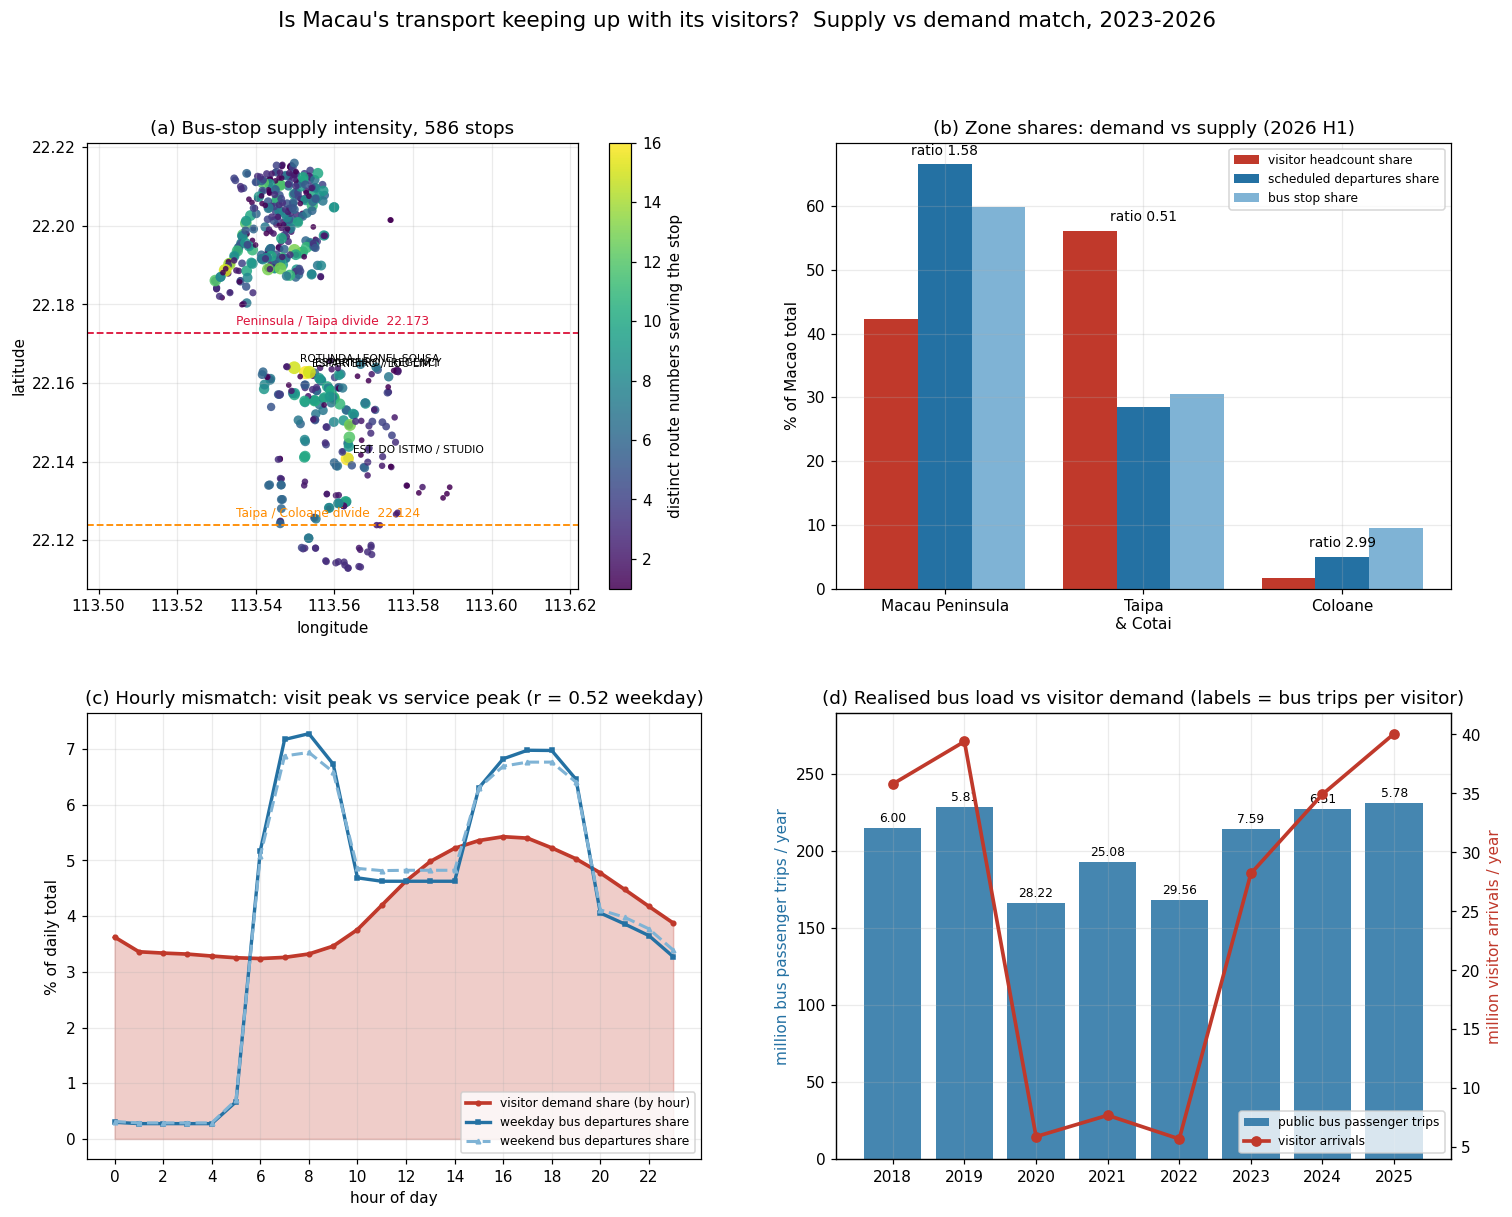

saved: C:\Users\07viv\Desktop\cisc7204-Assgn01-2026-mc653748\figures\fig1_research_question_supply_demand_match.png 422.8 KB


In [16]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.22)

ax = fig.add_subplot(gs[0, 0])
sc = ax.scatter(stops['lng'], stops['lat'], c=stops['n_routes'], s=10 + 4 * stops['n_routes'],
                cmap='viridis', alpha=0.85, edgecolors='none')
ax.axhline(PEN_THR, color='crimson', lw=1.2, ls='--')
ax.axhline(COL_THR, color='darkorange', lw=1.2, ls='--')
ax.text(113.535, PEN_THR + 0.002, 'Peninsula / Taipa divide  %.3f' % PEN_THR, color='crimson', fontsize=8)
ax.text(113.535, COL_THR + 0.002, 'Taipa / Coloane divide  %.3f' % COL_THR, color='darkorange', fontsize=8)
hot = stops.sort_values('n_routes', ascending=False).head(4)
for _, s in hot.iterrows():
    ax.annotate(str(s['namePor'])[:22], (s['lng'], s['lat']), fontsize=7, color='black',
                xytext=(4, 4), textcoords='offset points')
fig.colorbar(sc, ax=ax, label='distinct route numbers serving the stop')
ax.set_title('(a) Bus-stop supply intensity, 586 stops')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude'); ax.set_aspect('equal', adjustable='datalim')

ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(ZONE_ORDER)); w = 0.27
ax2.bar(x - w, match_zone['demand_share_pct'], w, label='visitor headcount share', color='#c0392b')
ax2.bar(x, match_zone['departures_share_pct'], w, label='scheduled departures share', color='#2471a3')
ax2.bar(x + w, match_zone['stops_share_pct'], w, label='bus stop share', color='#7fb3d5')
for i, z in enumerate(ZONE_ORDER):
    ax2.text(i, max(match_zone.loc[z, 'demand_share_pct'], match_zone.loc[z, 'departures_share_pct']) + 1.5,
             'ratio %.2f' % match_zone.loc[z, 'supply_demand_ratio'], ha='center', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels([z.replace(' & ', '\n& ') for z in ZONE_ORDER])
ax2.set_ylabel('% of Macao total'); ax2.legend(fontsize=8)
ax2.set_title('(b) Zone shares: demand vs supply (2026 H1)')

ax3 = fig.add_subplot(gs[1, 0])
ax3.fill_between(match_hour.index, match_hour['demand_share_pct'], color='#c0392b', alpha=0.25)
ax3.plot(match_hour.index, match_hour['demand_share_pct'], color='#c0392b', lw=2.4, marker='o', ms=3,
         label='visitor demand share (by hour)')
ax3.plot(match_hour.index, match_hour['supply_share_weekday_pct'], color='#2471a3', lw=2.2, marker='s', ms=3,
         label='weekday bus departures share')
ax3.plot(match_hour.index, match_hour['supply_share_weekend_pct'], color='#7fb3d5', lw=2.0, ls='--', marker='^', ms=3,
         label='weekend bus departures share')
ax3.set_xticks(range(0, 24, 2)); ax3.set_xlabel('hour of day'); ax3.set_ylabel('% of daily total')
ax3.set_title('(c) Hourly mismatch: visit peak vs service peak (r = %.2f weekday)' % r_wd)
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(al['year'], al['bus_passenger_trips'] / 1e6, color='#2471a3', alpha=0.85, label='public bus passenger trips')
ax4.set_ylabel('million bus passenger trips / year', color='#2471a3')
ax4.set_ylim(0, max(al['bus_passenger_trips'] / 1e6) * 1.25)
axb = ax4.twinx(); axb.grid(False)
axb.plot(al['year'], al['visitor_arrivals'] / 1e6, color='#c0392b', lw=2.4, marker='o', label='visitor arrivals')
axb.set_ylabel('million visitor arrivals / year', color='#c0392b')
for _, r_ in al.iterrows():
    ax4.text(r_['year'], r_['bus_passenger_trips'] / 1e6 + 4, '%.2f' % r_['trips_per_visitor'], ha='center', fontsize=8)
ax4.set_title('(d) Realised bus load vs visitor demand (labels = bus trips per visitor)')
h1, l1 = ax4.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax4.legend(h1 + h2, l1 + l2, fontsize=8, loc='lower right')

fig.suptitle('Is Macau\'s transport keeping up with its visitors?  Supply vs demand match, 2023-2026', fontsize=14)
f1 = os.path.join(FIGD, 'fig1_research_question_supply_demand_match.png')
fig.savefig(f1, dpi=170, bbox_inches='tight')
plt.show()
print('saved:', f1, round(os.path.getsize(f1) / 1024, 1), 'KB')


---
## 7. Figure 2 — supplementary view (district ranking, event crowding, Golden Weeks, shuttle channel)

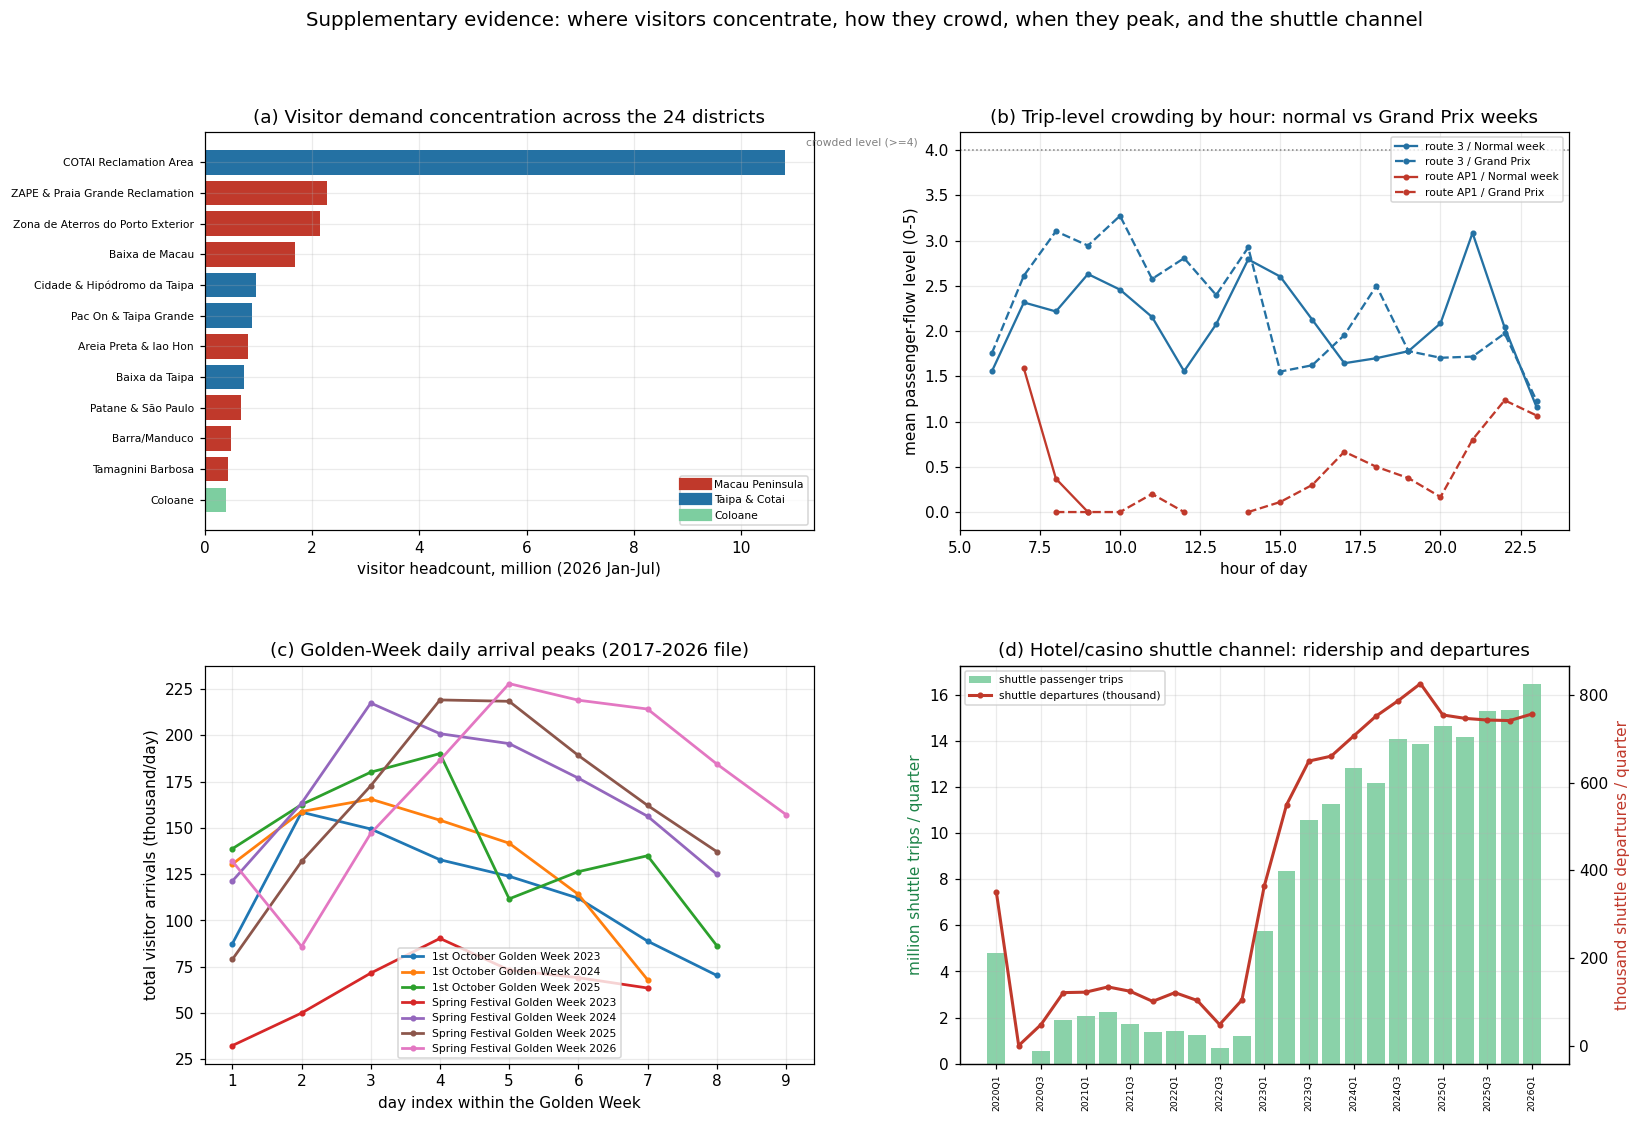

saved: C:\Users\07viv\Desktop\cisc7204-Assgn01-2026-mc653748\figures\fig2_supplementary_district_event_shuttle.png 475.8 KB


In [17]:
fig2 = plt.figure(figsize=(16, 11))
gs2 = fig2.add_gridspec(2, 2, hspace=0.34, wspace=0.24)

axa = fig2.add_subplot(gs2[0, 0])
top = p26.groupby(['district_en', 'zone'])['headcount'].sum().sort_values(ascending=False).head(12)
cols = {'Macau Peninsula': '#c0392b', 'Taipa & Cotai': '#2471a3', 'Coloane': '#7dcea0'}
axa.barh(range(len(top))[::-1], top.values / 1e6, color=[cols[z] for _, z in top.index])
axa.set_yticks(range(len(top))[::-1])
axa.set_yticklabels([n.replace('Novos Aterros do Porto Exterior & Aterros da Baía da Praia Grande', 'ZAPE & Praia Grande Reclamation')[:44] for n, _ in top.index], fontsize=7)
axa.set_xlabel('visitor headcount, million (2026 Jan-Jul)')
axa.set_title('(a) Visitor demand concentration across the 24 districts')
axa.legend(handles=[Line2D([0], [0], color=c, lw=8, label=z) for z, c in cols.items()], fontsize=7)

axb = fig2.add_subplot(gs2[0, 1])
for rte, colr in [('3', '#2471a3'), ('AP1', '#c0392b')]:
    for phase, ls in [('Normal week', '-'), ('Grand Prix', '--')]:
        d = mp[(mp.route == rte) & (mp.phase == phase)].dropna(subset=['crowd'])
        h = d.groupby('hour')['crowd'].mean()
        h = h.reindex(range(24))
        axb.plot(h.index, h.values, color=colr, ls=ls, marker='o', ms=3,
                 label='route %s / %s' % (rte, phase))
axb.axhline(4, color='grey', lw=1, ls=':')
axb.text(0.2, 4.05, 'crowded level (>=4)', fontsize=7, color='grey')
axb.set_xlim(5, 24); axb.set_xlabel('hour of day'); axb.set_ylabel('mean passenger-flow level (0-5)')
axb.set_title('(b) Trip-level crowding by hour: normal vs Grand Prix weeks')
axb.legend(fontsize=7)

axc = fig2.add_subplot(gs2[1, 0])
for lbl, g in gw[gw.year >= 2023].groupby('gw_label'):
    axc.plot(g['day_index'], g['arrivals'] / 1e3, marker='o', ms=3, lw=1.8, label=lbl)
axc.set_xlabel('day index within the Golden Week'); axc.set_ylabel('total visitor arrivals (thousand/day)')
axc.set_title('(c) Golden-Week daily arrival peaks (2017-2026 file)')
axc.legend(fontsize=7)

axd = fig2.add_subplot(gs2[1, 1])
sh2 = sh.dropna(subset=['ridership']).copy()
axd.bar(np.arange(len(sh2)), sh2['ridership'] / 1e6, color='#7dcea0', alpha=0.9, label='shuttle passenger trips')
axd.set_ylabel('million shuttle trips / quarter', color='#1e8449')
axd.set_xticks(np.arange(len(sh2))[::2]); axd.set_xticklabels(list(sh2['period'])[::2], rotation=90, fontsize=6)
axd2 = axd.twinx(); axd2.grid(False)
if 'departures' in sh2:
    axd2.plot(np.arange(len(sh2)), sh2['departures'] / 1e3, color='#c0392b', lw=2, marker='o', ms=3,
              label='shuttle departures (thousand)')
    axd2.set_ylabel('thousand shuttle departures / quarter', color='#c0392b')
axd.set_title('(d) Hotel/casino shuttle channel: ridership and departures')
h1, l1 = axd.get_legend_handles_labels(); h2, l2 = axd2.get_legend_handles_labels()
axd.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper left')

fig2.suptitle('Supplementary evidence: where visitors concentrate, how they crowd, when they peak, and the shuttle channel', fontsize=13)
f2 = os.path.join(FIGD, 'fig2_supplementary_district_event_shuttle.png')
fig2.savefig(f2, dpi=170, bbox_inches='tight')
plt.show()
print('saved:', f2, round(os.path.getsize(f2) / 1024, 1), 'KB')


---
## 8. Export: merged analysis dataset (CSV) and SQLite database

In [18]:
master = p26.merge(dist_lookup, on=['district_cn', 'district_en', 'zone'], how='left')
master = master.merge(match_zone[['daily_bus_departures', 'departures_share_pct', 'supply_demand_ratio']],
                      left_on='zone', right_index=True, how='left')
month_arr = dem[['year', 'month', 'arrivals']].rename(columns={'arrivals': 'month_total_arrivals'})
master = master.merge(month_arr, on=['year', 'month'], how='left')
master['month_arrivals_per_district_hour'] = master['month_total_arrivals'] / master.groupby(['year', 'month'])['district_cn'].transform('nunique') / 24
cols = ['year', 'month', 'hour', 'period', 'district_cn', 'district_en', 'zone', 'headcount',
        'month_total_arrivals', 'daily_bus_departures', 'departures_share_pct', 'supply_demand_ratio']
master = master[cols]
mpath = os.path.join(PROC, 'analysis_dataset_master.csv')
master.to_csv(mpath, index=False, encoding='utf-8-sig')
print('merged analysis dataset:', mpath, master.shape)

db = os.path.join(PROC, 'macau_visitor_transport.sqlite')
if os.path.exists(db):
    os.remove(db)
con = sqlite3.connect(db)
tables = {
    'dataset_inventory': inv_df, 'dim_district': dist_lookup, 'demand_monthly_arrivals': dem,
    'demand_district_hour_panel': panel, 'demand_district_hour_2026': p26,
    'demand_goldenweek_daily': gw, 'supply_stops': stops, 'supply_routes': rdf,
    'supply_departures_route_hour': dep, 'supply_stop_departures': stop_dep,
    'supply_official_series': off, 'supply_shuttle_quarterly': sh,
    'match_zone_supply_demand': match_zone.reset_index().rename(columns={'index': 'zone'}),
    'match_hourly_profile': match_hour.reset_index().rename(columns={'index': 'hour'}),
    'match_gateways': gwdf, 'match_event_crowding': ev.reset_index(),
    'match_annual_alignment': al, 'analysis_master': master,
}
for name, frame in tables.items():
    f = frame.copy()
    f.columns = [str(c) for c in f.columns]
    f.to_sql(name, con, index=False, if_exists='replace')
cur = con.cursor()
rows = cur.execute("SELECT name, (SELECT COUNT(*) FROM sqlite_master m2 WHERE m2.name=m1.name) FROM sqlite_master m1 WHERE type='table' ORDER BY name").fetchall()
print('\nSQLite tables written:', len(rows))
for n, _ in rows:
    cnt = cur.execute('SELECT COUNT(*) FROM "%s"' % n).fetchone()[0]
    print('   %-32s %6d rows' % (n, cnt))
con.commit(); con.close()
print('sqlite:', db, round(os.path.getsize(db) / 1024, 1), 'KB')


merged analysis dataset: C:\Users\07viv\Desktop\cisc7204-Assgn01-2026-mc653748\data_processed\analysis_dataset_master.csv (4032, 12)

SQLite tables written: 18
   analysis_master                    4032 rows
   dataset_inventory                    18 rows
   demand_district_hour_2026          4032 rows
   demand_district_hour_panel        24768 rows
   demand_goldenweek_daily             140 rows
   demand_monthly_arrivals             224 rows
   dim_district                         24 rows
   match_annual_alignment                8 rows
   match_event_crowding                  4 rows
   match_gateways                        7 rows
   match_hourly_profile                 24 rows
   match_zone_supply_demand              3 rows
   supply_departures_route_hour       7488 rows
   supply_official_series              182 rows
   supply_routes                        91 rows
   supply_shuttle_quarterly             25 rows
   supply_stop_departures              586 rows
   supply_stops         

---
## 9. Phase-1 outputs and what they feed into the proposal

In [19]:
outs = []
for folder in (PROC, FIGD):
    for f in sorted(os.listdir(folder)):
        p = os.path.join(folder, f)
        if os.path.isfile(p):
            outs.append({'file': f, 'folder': os.path.basename(folder), 'size_kb': round(os.path.getsize(p) / 1024, 1)})
out_df = pd.DataFrame(outs)
display(out_df)

arr26 = int(dem[(dem.year == 2026) & (dem.month <= 8)].arrivals.sum())
cotai = match_zone.loc['Taipa & Cotai', 'demand_share_pct']
pen = match_zone.loc['Macau Peninsula', 'demand_share_pct']
under = match_zone['supply_demand_ratio'].idxmin()
lines = [
    'Headline phase-1 findings to carry into the proposal:',
    ' 1. Demand is at record level: 2025 = %s arrivals; 2026 Jan-Aug = %s (YoY +%.1f%%).' % (
        f"{int(dem[dem.year == 2025].arrivals.sum()):,}", f"{arr26:,}",
        100 * (dem[dem.year == 2026].head(8).arrivals.sum() / dem[dem.year == 2025].head(8).arrivals.sum() - 1)),
    ' 2. Demand is heavy-tailed in space: %s holds %.1f%% of all district-hour visitor headcount vs %.1f%% for %s.' % (
        'Taipa & Cotai', cotai, pen, 'Macau Peninsula'),
    ' 3. Service peaks (07-09h and 17-19h commuting) do not coincide with visitor demand peaks (late morning to evening):',
    '    hour-of-day Pearson r = %.3f (weekday) / %.3f (weekend) - the quantitative core of the gap.' % (r_wd, r_we),
    ' 4. Zone supply/demand ratio is lowest for: %s (%.2f) - the zone that looks structurally under-served relative to visitor load.' % (
        under, match_zone.loc[under, 'supply_demand_ratio']),
    ' 5. Gateways and Golden Weeks concentrate demand spikes while scheduled departures stay flat;',
    '    during Grand Prix weeks mean crowding rises on the routes serving visitor districts (routes 3 and AP1).',
    'Caveat: all statements are associational (shares, gaps, correlations) - no causal claim about visitation.',
]
print('\n'.join(lines))


,file,folder,size_kb
0,analysis_dataset_master.csv,data_processed,426.6
1,dataset_inventory.csv,data_processed,3.3
2,demand_district_hour_2026.csv,data_processed,305.8
3,demand_district_hour_panel_2023_2026.csv,data_processed,1881.6
4,demand_goldenweek_daily.csv,data_processed,19.6
5,demand_monthly_arrivals.csv,data_processed,13.8
6,macau_visitor_transport.sqlite,data_processed,3316.0
7,match_annual_alignment.csv,data_processed,0.4
8,match_event_crowding.csv,data_processed,0.2
9,match_event_segment_crowding.csv,data_processed,2.9


Headline phase-1 findings to carry into the proposal:
 1. Demand is at record level: 2025 = 40,069,360 arrivals; 2026 Jan-Aug = 28,964,737 (YoY +7.7%).
 2. Demand is heavy-tailed in space: Taipa & Cotai holds 56.1% of all district-hour visitor headcount vs 42.2% for Macau Peninsula.
 3. Service peaks (07-09h and 17-19h commuting) do not coincide with visitor demand peaks (late morning to evening):
    hour-of-day Pearson r = 0.524 (weekday) / 0.547 (weekend) - the quantitative core of the gap.
 4. Zone supply/demand ratio is lowest for: Taipa & Cotai (0.51) - the zone that looks structurally under-served relative to visitor load.
 5. Gateways and Golden Weeks concentrate demand spikes while scheduled departures stay flat;
    during Grand Prix weeks mean crowding rises on the routes serving visitor districts (routes 3 and AP1).
Caveat: all statements are associational (shares, gaps, correlations) - no causal claim about visitation.
